**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

*   NOMBRE: Mónica María Ramírez Mejía
*   MATRÍCULA: A01797493

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia y Analitica de Datos/Tareas/Semana9"
os.chdir(DIR)
cancer_df = pd.read_csv('breast_cancer.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cancer_df.set_index('id', inplace=True)

In [ ]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

Númericas: 30, Texto: 1

In [ ]:
(cancer_df.isna().sum() / len(cancer_df) * 100).sort_values(ascending=False)

,0
diagnosis,0.0
radius_mean,0.0
texture_mean,0.0
perimeter_mean,0.0
area_mean,0.0
smoothness_mean,0.0
compactness_mean,0.0
concavity_mean,0.0
concave points_mean,0.0
symmetry_mean,0.0


In [ ]:
cancer_df.duplicated().sum()

np.int64(0)

In [ ]:
cancer_df = cancer_df.drop_duplicates().reset_index(drop=True)

In [ ]:
num_cols = cancer_df.select_dtypes(include = ['float64']).columns.tolist()
cat_cols = cancer_df.select_dtypes(include = ['object']).columns.tolist()

In [ ]:
pd.concat([cancer_df[num_cols].describe().T, cancer_df[num_cols].kurt().rename('curtosis'), cancer_df[num_cols].skew().rename('simetria')], axis=1)

,count,mean,std,min,25%,50%,75%,max,curtosis,simetria
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.845522,0.942380
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.758319,0.650450
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.972214,0.990650
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,3.652303,1.645732
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.855975,0.456324
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.650130,1.190123
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.998638,1.401180
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.066556,1.171180
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,1.287933,0.725609
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,3.005892,1.304489


In [ ]:
cancer_df[cat_cols].describe(include = ['object']).T

,count,unique,top,freq
diagnosis,569,2,B,357


2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

In [ ]:
cancer_df.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


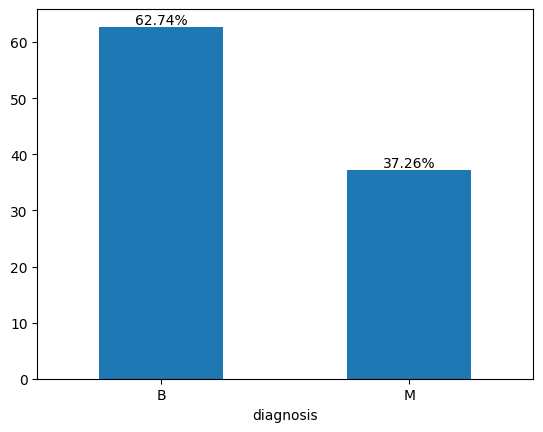

In [ ]:
porcentajes = cancer_df['diagnosis'].value_counts(normalize=True) * 100
ax = porcentajes.plot(kind='bar', rot=0)
for i, v in enumerate(porcentajes):
    ax.text(i, v + 0.5, f'{v:.2f}%', ha='center')

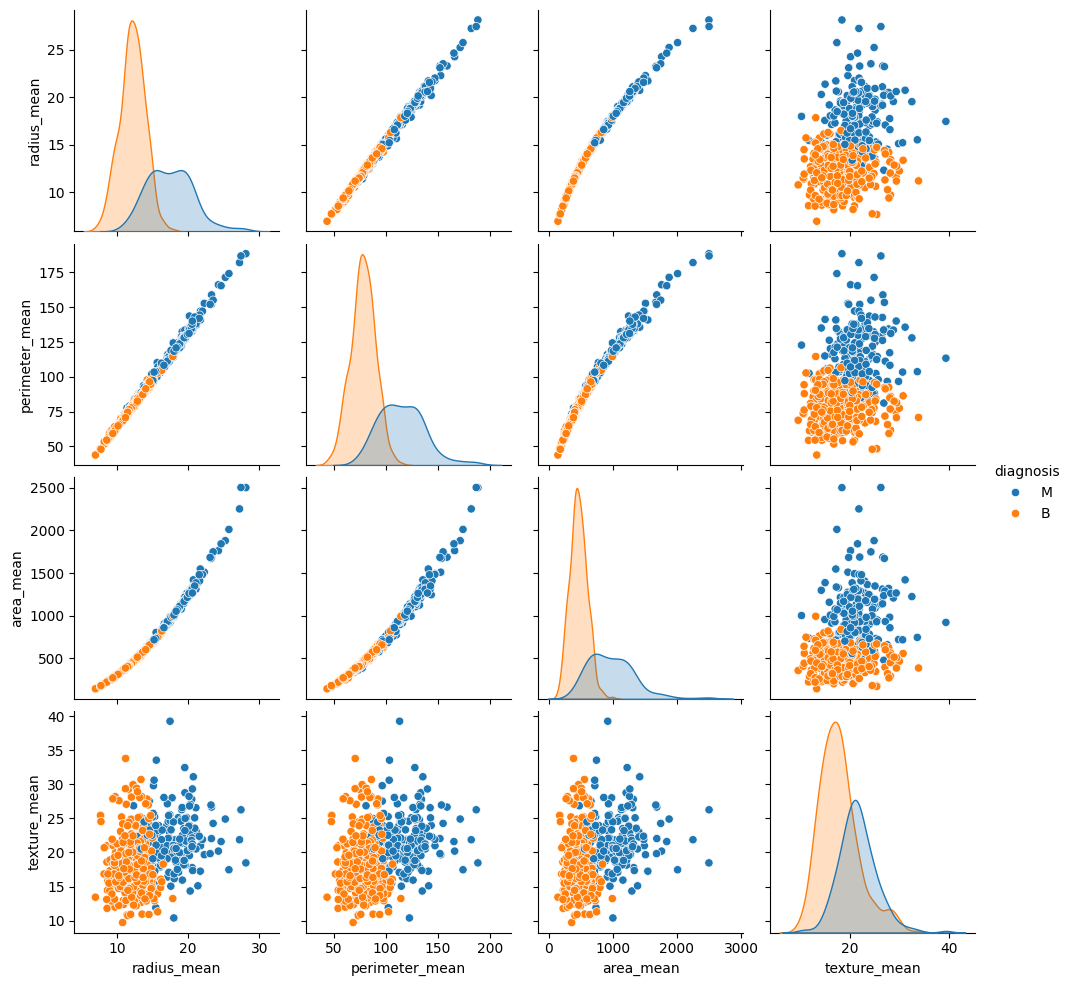

In [ ]:
sns.pairplot(cancer_df,
             vars= cancer_df[['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean']],
             hue='diagnosis')

Se observa que las variables radius_mean, perimeter_mean y area_mean tienen una fuerte relación, es decir, cuando una aumenta lo hacen las demás. Además, es posible notar que estas variables tienen valores mas altos cuando el tumor es maligno. Por otro lado, texture_mean no muestra una relacion tan clara.

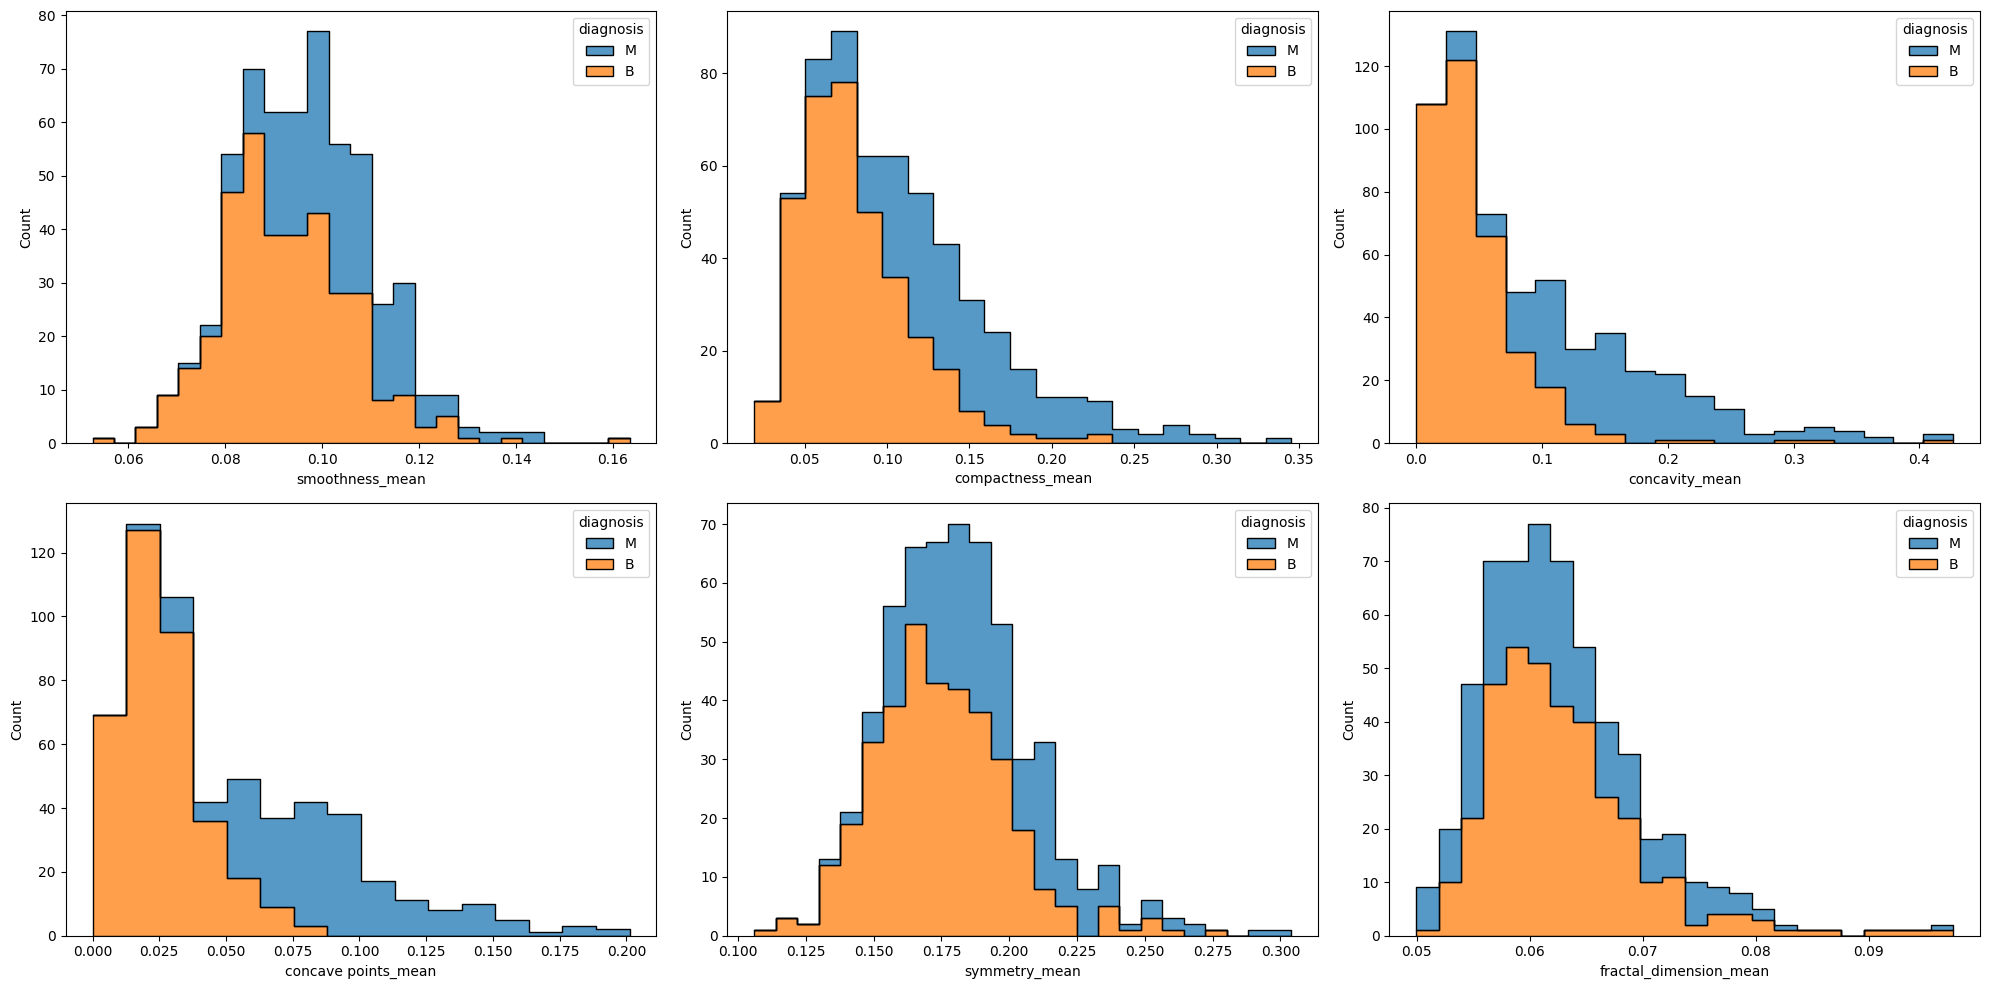

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
for var, ax in zip(cancer_df[['smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']], axes.flatten()):
    sns.histplot(
        data=cancer_df,
        x=var,
        hue='diagnosis',
        multiple='stack',
        element='step',
        ax=ax
    )
plt.tight_layout()
plt.show()

Las variables que representan una mejor separación entre clases son concave points_mean y tambien concavity_mean. Dado que se distinguen mejor las barras azules y anaranjadas.

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [ ]:
cancer_copy = cancer_df.copy()

In [ ]:
corr = round(cancer_copy.corr(numeric_only=True), 2)
corr_variables = corr[(corr > 0.9) & (corr < 1.0)].dropna(how='all', axis=0).dropna(how='all', axis=1)
corr_variables

,radius_mean,texture_mean,perimeter_mean,area_mean,concavity_mean,concave points_mean,radius_se,perimeter_se,area_se,radius_worst,texture_worst,perimeter_worst,area_worst,concave points_worst
radius_mean,NaN,NaN,NaN,0.99,NaN,NaN,NaN,NaN,NaN,0.97,NaN,0.97,0.94,NaN
texture_mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.91,NaN,NaN,NaN
perimeter_mean,NaN,NaN,NaN,0.99,NaN,NaN,NaN,NaN,NaN,0.97,NaN,0.97,0.94,NaN
area_mean,0.99,NaN,0.99,NaN,NaN,NaN,NaN,NaN,NaN,0.96,NaN,0.96,0.96,NaN
concavity_mean,NaN,NaN,NaN,NaN,NaN,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
concave points_mean,NaN,NaN,NaN,NaN,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.91
radius_se,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.95,NaN,NaN,NaN,NaN,NaN
perimeter_se,NaN,NaN,NaN,NaN,NaN,NaN,0.97,NaN,0.94,NaN,NaN,NaN,NaN,NaN
area_se,NaN,NaN,NaN,NaN,NaN,NaN,0.95,0.94,NaN,NaN,NaN,NaN,NaN,NaN
radius_worst,0.97,NaN,0.97,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.99,0.98,NaN


In [ ]:
cancer_copy.drop(columns = ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'], inplace = True)

In [ ]:
cancer_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         569 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           569 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
 11  radius_se               569 non-null    float64
 12  texture_se              569 non-null    float64
 13  perimeter_se            569 non-null    float64
 14  area_se                 569 non-null    fl

In [ ]:
corr = round(cancer_copy.corr(numeric_only=True), 2)
corr_variables = corr[(corr > 0.9) & (corr < 1.0)].dropna(how='all', axis=0).dropna(how='all', axis=1)
corr_variables

,radius_mean,perimeter_mean,area_mean,concavity_mean,concave points_mean,radius_se,perimeter_se,area_se
radius_mean,NaN,NaN,0.99,NaN,NaN,NaN,NaN,NaN
perimeter_mean,NaN,NaN,0.99,NaN,NaN,NaN,NaN,NaN
area_mean,0.99,0.99,NaN,NaN,NaN,NaN,NaN,NaN
concavity_mean,NaN,NaN,NaN,NaN,0.92,NaN,NaN,NaN
concave points_mean,NaN,NaN,NaN,0.92,NaN,NaN,NaN,NaN
radius_se,NaN,NaN,NaN,NaN,NaN,NaN,0.97,0.95
perimeter_se,NaN,NaN,NaN,NaN,NaN,0.97,NaN,0.94
area_se,NaN,NaN,NaN,NaN,NaN,0.95,0.94,NaN


Mantendria el radio, ya que en un circulo o esfera el perimetro y el area dependen de este.

In [ ]:
cancer_copy.drop(columns = ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se'], inplace = True)

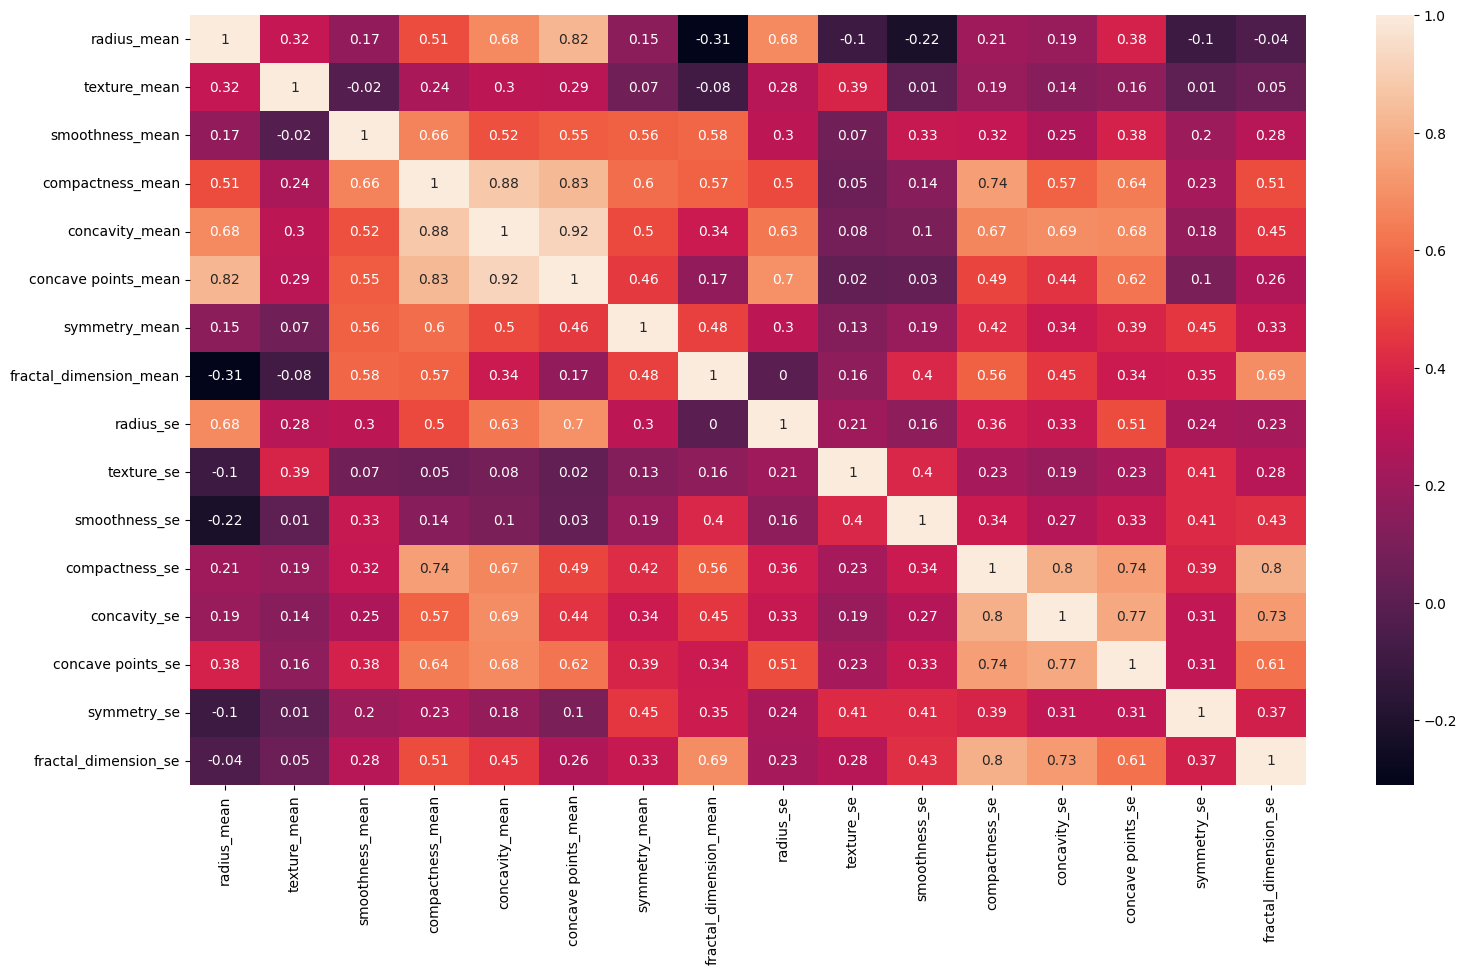

In [ ]:
plt.figure(figsize = (18, 10))
sns.heatmap(round(cancer_copy.corr(numeric_only=True),2), annot = True)
plt.show()

In [ ]:
corr = round(cancer_copy.corr(numeric_only=True), 2)
corr_variables = corr[(corr > 0.9) & (corr < 1.0)].dropna(how='all', axis=0).dropna(how='all', axis=1)
corr_variables

,concavity_mean,concave points_mean
concavity_mean,NaN,0.92
concave points_mean,0.92,NaN


In [ ]:
cancer_copy.drop(columns = ['concavity_mean'], inplace = True)

Segun la descripcion de las variables, concavity y concave points contienen informacion similar, por lo que podria causar redundancia por su alta correlacion. Se conservará concave points_mean

In [ ]:
cancer_copy.head(5)

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
0,M,17.99,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
1,M,20.57,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
2,M,19.69,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
3,M,11.42,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
4,M,20.29,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115


4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [ ]:
cancer_df.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [ ]:
X = cancer_df.drop('diagnosis', axis = 1)
y = cancer_df['diagnosis']

In [ ]:
y = np.where(y == 'M', 1, 0)

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=1)

In [ ]:
def evaluate_model(ytest, predicted):
    return {
        'Recall': recall_score(ytest, predicted),
        'Precision': precision_score(ytest, predicted),
        'Accuracy': accuracy_score(ytest, predicted)
    }

5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [ ]:
preprocessing = ColumnTransformer([
    ('borrar_correlacionadas', 'drop', [
        'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst',
        'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'concavity_mean'
    ])
], remainder='passthrough')

In [ ]:
logistic_reg = make_pipeline(preprocessing, LogisticRegression())

In [ ]:
logistic_reg.fit(Xtrain, ytrain)
predictions = logistic_reg.predict(Xtest)
evaluate_model(ytest, predictions)

{'Recall': 0.7619047619047619,
 'Precision': 0.8888888888888888,
 'Accuracy': 0.8771929824561403}

In [ ]:
metrics = evaluate_model(ytest, predictions)
resultado = pd.DataFrame({
  'Modelo': ['Correlation_Clean'],
  'Recall': [metrics['Recall']],
  'Precision': [metrics['Precision']],
  'Accuracy': [metrics['Accuracy']]
})
resultado

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [ ]:
logistic_reg2 = make_pipeline(preprocessing, StandardScaler(), PCA(n_components=0.90), LogisticRegression())

In [ ]:
logistic_reg2.fit(Xtrain, ytrain)
predictions = logistic_reg2.predict(Xtest)
evaluate_model(ytest, predictions)

{'Recall': 0.8809523809523809,
 'Precision': 0.9487179487179487,
 'Accuracy': 0.9385964912280702}

In [ ]:
metrics2 = evaluate_model(ytest, predictions)
ss_pca_logr = pd.DataFrame({
  'Modelo': ['Standard_PCA'],
  'Recall': [metrics2['Recall']],
  'Precision': [metrics2['Precision']],
  'Accuracy': [metrics2['Accuracy']]
})
resultado = pd.concat([resultado, ss_pca_logr])
resultado

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
0,Standard_PCA,0.880952,0.948718,0.938596


In [ ]:
logistic_reg2.named_steps['pca'].n_components_

np.int64(7)

Se usaron 7 componentes principales

7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [ ]:
logistic_reg3 = make_pipeline(preprocessing, PowerTransformer(method= 'yeo-johnson'), LogisticRegression())

In [ ]:
logistic_reg3.fit(Xtrain, ytrain)
predictions = logistic_reg3.predict(Xtest)
evaluate_model(ytest, predictions)

{'Recall': 0.9523809523809523,
 'Precision': 1.0,
 'Accuracy': 0.9824561403508771}

In [ ]:
metrics3 = evaluate_model(ytest, predictions)
yeo_logr = pd.DataFrame({
  'Modelo': ['Correlation_Yeo'],
  'Recall': [metrics3['Recall']],
  'Precision': [metrics3['Precision']],
  'Accuracy': [metrics3['Accuracy']]
})
resultado = pd.concat([resultado, yeo_logr])
resultado

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
0,Standard_PCA,0.880952,0.948718,0.938596
0,Correlation_Yeo,0.952381,1.000000,0.982456


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

In [ ]:
logistic_reg3.named_steps['columntransformer'].get_feature_names_out()

array(['remainder__radius_mean', 'remainder__texture_mean',
       'remainder__smoothness_mean', 'remainder__compactness_mean',
       'remainder__concave points_mean', 'remainder__symmetry_mean',
       'remainder__fractal_dimension_mean', 'remainder__radius_se',
       'remainder__texture_se', 'remainder__smoothness_se',
       'remainder__compactness_se', 'remainder__concavity_se',
       'remainder__concave points_se', 'remainder__symmetry_se',
       'remainder__fractal_dimension_se'], dtype=object)

In [ ]:
len(preprocessing.get_feature_names_out())

15

In [ ]:
coef = logistic_reg3.named_steps['logisticregression'].coef_[0]
features = logistic_reg3.named_steps['columntransformer'].get_feature_names_out()
coef_magnitud = pd.DataFrame({
    'Variable': features,
    'Coeficiente': coef
}).sort_values(by='Coeficiente', ascending=False)
coef_magnitud

,Variable,Coeficiente
4,remainder__concave points_mean,2.467117
1,remainder__texture_mean,1.906850
0,remainder__radius_mean,1.379170
7,remainder__radius_se,1.320211
11,remainder__concavity_se,1.012023
5,remainder__symmetry_mean,0.783896
3,remainder__compactness_mean,0.624829
2,remainder__smoothness_mean,0.533570
9,remainder__smoothness_se,-0.287566
6,remainder__fractal_dimension_mean,-0.290222


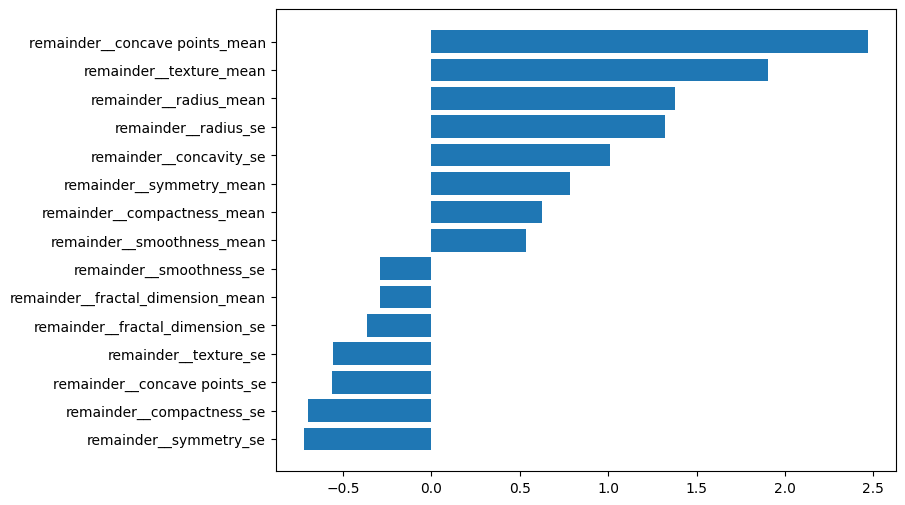

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(coef_magnitud['Variable'], coef_magnitud['Coeficiente'])
plt.gca().invert_yaxis()
plt.show()

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

In [ ]:
resultado

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
0,Standard_PCA,0.880952,0.948718,0.938596
0,Correlation_Yeo,0.952381,1.000000,0.982456


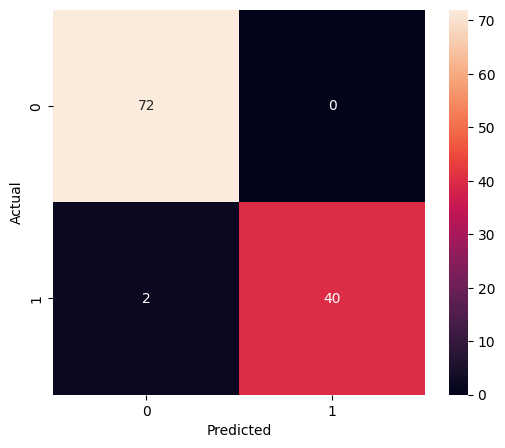

In [ ]:
cm = confusion_matrix(ytest, predictions, labels= logistic_reg3.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
   xticklabels=logistic_reg3.classes_,
   yticklabels=logistic_reg3.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

El modelo clasificó correctamente 72 casos de cancer benignos y 40 malignos. Ademas, hubieron 2 casos de cancer maligno no detectados. Lo anterior evidencia una muy buena capacidad de clasificacion y muy pocos errores criticos.

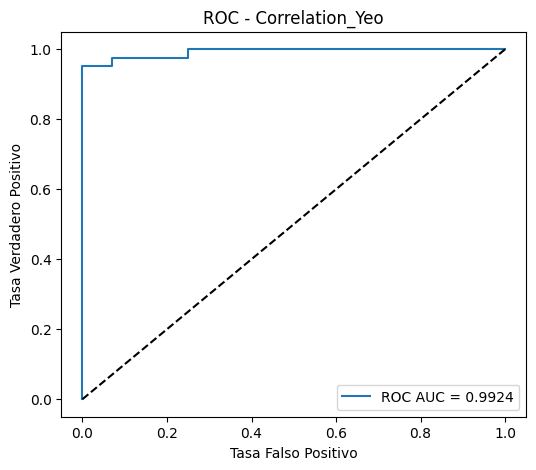

In [ ]:
y_prob = logistic_reg3.predict_proba(Xtest)[:, 1]
fpr, tpr, _ = roc_curve(ytest, y_prob)
roc_auc = roc_auc_score(ytest, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa Falso Positivo')
plt.ylabel('Tasa Verdadero Positivo')
plt.title('ROC - Correlation_Yeo')
plt.legend(loc='lower right')
plt.show()

La grafica muestra una curva ROC AUC de 0.99, lo que significa que el modelo acierta casi siempre al separar los casos positivos de los negativos. Es decir, que distingue casi perfectamente entre pacientes con y sin cáncer.

10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

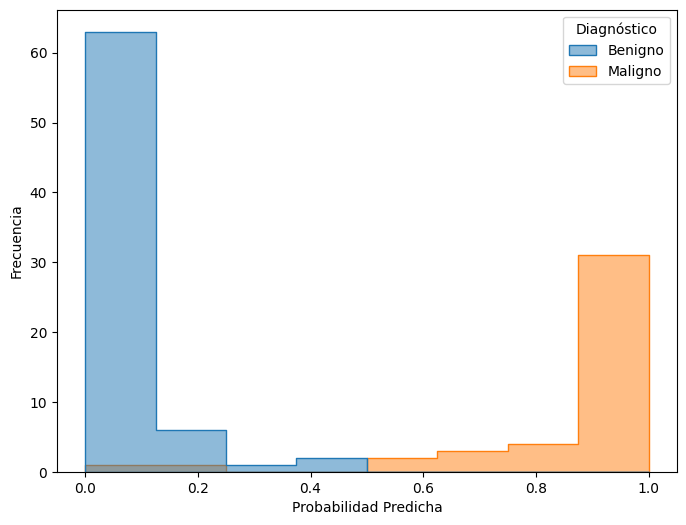

In [ ]:
df_probs = pd.DataFrame({'Probabilidad': y_prob, 'Diagnóstico': ytest})
df_probs['Diagnóstico'] = df_probs['Diagnóstico'].map({0: 'Benigno', 1: 'Maligno'})
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(
    data=df_probs,
    x='Probabilidad',
    hue='Diagnóstico',
    multiple='layer',
    alpha=0.5,
    element='step',
    ax=ax
)
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.show()

1.   Umbral por defecto: 0.5
2.   Metrica mas importante en modelo medico: Recall, porque estima casos reales que se detectaron de manera correcta.
3. cambiar (disminuir / aumentar) threshold: disminuir para aumentar el recall y detectar mas pacientes con cancer.